# Exploratory Data Analysis: Association Analysis Between 2 Numerical Variables

When analyzing 2 numerical variables, we generally interested in the  relationship or pattern that the 2 numerical variable can form.

We can obtain those pattern/relationship through:
* Numerical way
* Graphical way

Throughout the next few exercises, we’ll examine some data about Texas housing rentals on Craigslist — an online classifieds site.

In [ ]:
import pandas as pd
housing = pd.read_csv("housing_sample.csv")

housing.head()

|	|price|	type|	sqfeet|	beds	|baths|	lat	|long|
|---|---|---|---|---|---|---|---|
|0|	615	|apartment|	364|	0|	1.0	|35.1653|	-101.884|
|1|	1346|	apartment|	816	|1	|1.0|	32.9865|	-96.686|
|2|	900|	apartment|	500|	1	|1.0|	30.2355|	-97.7292|
|3|	650	|apartment|	700	|1	|1.0|	26.1923	|-98.2657|
|4|	1330|	apartment|	1040|	2|	2.0	|30.638|	-96.294|

The data dictionary is as follows:

* price: monthly rental price in U.S.D.
* type: type of housing (eg., 'apartment', 'house', 'condo', etc.)
* sqfeet: housing area, in square feet
* beds: number of beds
* baths: number of baths
* lat: latitude
* long: longitude

## Graphical way of Association Analysis

One of the best ways to quickly visualize the relationship between quantitative variables is to plot them against each other in a scatter plot. 

This makes it easy to look for patterns or trends in the data. 

To create a scatter plot from python:

syntax:

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x = df_name.column_name1, y = df_name.column_name2)
plt.show()
plt.close()

Additional function can helps to add more useful information on the scatterplot: 

In [ ]:
plt.xlabel("x-axis_name")
plt.ylabel("y-axis_name")

plt.xlabel() adds name to the x-axis
plt.ylabel() adds name to the y-axis

Example:

Let’s start by plotting the area of a rental against its monthly price to see if we can spot any patterns.

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x = housing.price, y = housing.sqfeet)
plt.xlabel('Rental Price (USD)')
plt.ylabel('Area (Square Feet)')

plt.show()
plt.close()

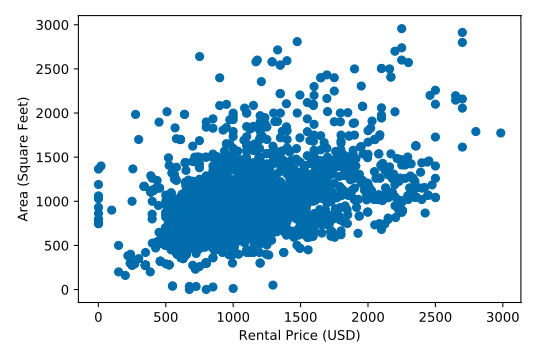

While there’s a lot of variation in the data, it seems like more expensive housing tends to come with slightly more space. This suggests an association between these two variables.

It’s important to note that different kinds of associations can lead to different patterns in a scatter plot. 

For example, the following plot shows the relationship between the age of a child in months and their weight in pounds:

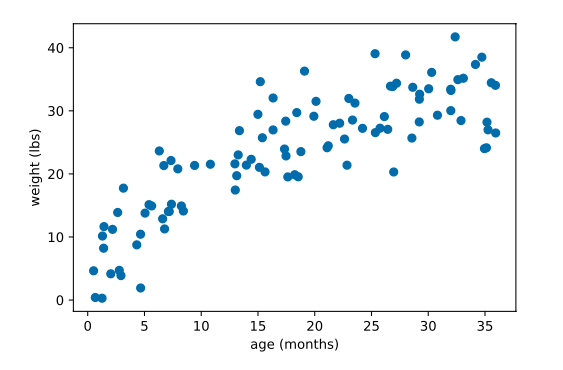 

We can see that older children tend to weigh more but that the growth rate starts leveling off after 36 months:

If we don’t see any patterns in a scatter plot, we can probably guess that the variables are not associated. For example, a scatter plot like this would suggest no association:

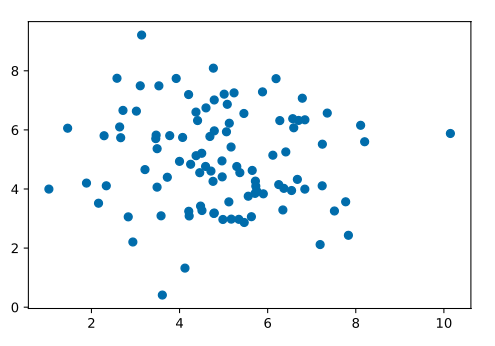

## Numerical way of Association Analysis

Beyond visualizing relationships, we can also use summary statistics to quantify the strength of certain associations. 

### Covariance

Covariance is a summary statistic that describes the strength of a linear relationship. 
A linear relationship is one where a straight line would best describe the pattern of points in a scatter plot.

Covariance can range from negative infinity to positive infinity. 
* A positive covariance indicates that a larger value of one variable is associated with a larger value of the other. 
* A negative covariance indicates a larger value of one variable is associated with a smaller value of the other. 
* A covariance of 0 indicates no linear relationship.

Here are some examples:

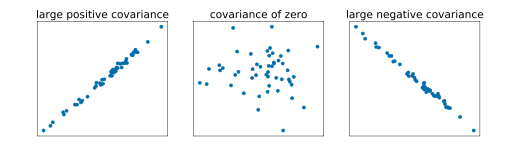

To calculate covariance, we can use the cov() function from NumPy, which produces a covariance matrix for two or more variables.

syntax:

In [ ]:
import numpy as np

var_name = np.cov(df_name.column_name1, df_name.column_name2)
print(var_name)

Output:

| |df_name.column_name1 |df_name.column_name2|
|---|---|---|
|df_name.column_name1|Variance(df_name.column_name1)|Covariance(df_name.column_name1, df_name.column_name2)|
|df_name.column_name2|Covariance(df_name.column_name1, df_name.column_name2)|Variance(df_name.column_name2)|

Since the Covariance is at the index position of [1][0] or [0][1], so to access it:

In [ ]:
import numpy as np

var_name = np.cov(df_name.column_name1, df_name.column_name2)
print(var_name[1][0])
#or
print(var_name[0][1])

Example:

We are interested in finding the covariance of the area of a rental against its monthly price.

In [ ]:
import numpy as np

cov_mat_price_sqfeet = np.cov(housing.price, housing.sqfeet)
print(cov_mat_price_sqfeet)

In [ ]:
#output: 
[[184332.9  57336.2]
 [ 57336.2 122045.2]]

In [ ]:
#covariance:
print(cov_mat_price_sqfeet[0][1])

In [ ]:
#output:
57336.2

### Correlation

Like covariance, Pearson Correlation (often referred to simply as “correlation”) is a scaled form of covariance. 

It also measures the strength of a linear relationship, but ranges from -1 to +1, making it more interpretable:
* Highly associated variables with a positive linear relationship will have a correlation close to 1. 
* Highly associated variables with a negative linear relationship will have a correlation close to -1. 
* Variables that do not have a linear association (or a linear association with a slope of zero) will have correlations close to 0.

Generally, A correlation:
* larger than about 0.3 indicates a linear association. 
* greater than about 0.6 suggestions a strong linear association.

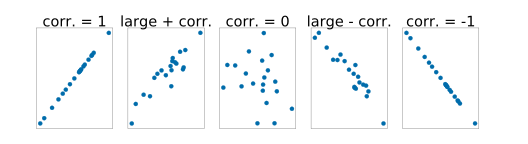

To calculate pearson correlation coefficient in python:

syntax:

In [ ]:
from scipy.stats import pearsonr

var_name = pearsonr(df_name.column_name1, df_name.column_name2)
print(var_name)

The output of peatsonr() gives 2 values:
 * Pearson Correlation Coefficient
 * p-value for testing non-correlation
 
 Pearson Correlation Test is testing for
 * Null hypothesis:
     * pearson correlation (p) is zero (no linear relationship)
 * Alternative hypothesis:
     * pearson correlation (p) is not zero (there is linear relationship)

Example:

We are interested in finding the Pearson Correlation Coefficient of the area of a rental against its monthly price.

In [ ]:
from scipy.stats import pearsonr

corr_price_sqfeet, p = pearsonr(housing.price, housing.sqfeet)
print(corr_price_sqfeet) 

In [ ]:
#output: 
(0.5070065351127468, 1e-323)

The Pearson Correlation Coefficient is 0.507.

Since the p-value of the Pearson Correlation Test is very close to 0, so we can conclude that the population pearson correlation coefficient is non-zero.

### Correlation Coefficient- Nonlinear relationship

It’s important to note that there are some limitations to using correlation or covariance as a way of assessing whether there is an association between two variables. 

Because correlation and covariance both measure the strength of linear relationships with non-zero slopes, but not other kinds of relationships, correlation can be misleading.

For example, the four scatter plots below all show pairs of variables with near-zero correlations. The bottom left image shows an example of a perfect linear association where the slope is zero (the line is horizontal). Meanwhile, the other three plots show non-linear relationships — if we drew a line through any of these sets of points, that line would need to be curved, not straight!

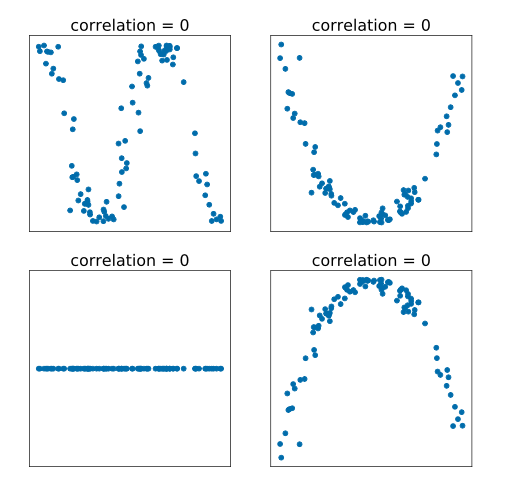